# Analiza przestrzeni latentnej — W2V vs MERT

Sprawdzamy, czy **zamrożone** embeddingi (mean-pool po czasie z `[1500, 2048]`) dają już widoczną separację bonafide vs spoof.

- **W2V** — `[:, :1024]`
- **MERT** — `[:, 1024:]`
- **Concat** — cały wektor `[2048]`

Używamy **podzbioru** (stratyfikowany, zbalansowany), żeby t-SNE było szybkie i czytelne. Metryki pomocnicze: silhouette, EER z linear probe na tym samym podzbiorze.

**Sekcja 5–6 (najważniejsza na tym etapie):** kierunek **probe trenowanego na Sonics train** + ranking wymiarów (|coef LR|, Fisher). To łączy wykresy z `linear_probe.ipynb` — widać, *który* kierunek w 1024D transferuje na MoM, a nie tylko czy chmury „ładnie wyglądają”.

> Uruchom na węźle z RAM (np. `salloc --mem=32G`), nie na login node — ładowanie wielu `.npy` może zużyć pamięć.

In [ ]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from torchmetrics.classification import EER
from tqdm.auto import tqdm

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.utils.dataset import parse_split_label, parse_split_label_mom

SCRATCH = Path("/net/people/plgrid/plgjedrzejkusnierz/scratch/data")
SONICS_POOLED = SCRATCH / "Sonics/preprocessed_pooled_merged"
MOM_POOLED = SCRATCH / "MoM/preprocessed_pooled_fp16"

CACHE_DIR = ROOT / "notebooks" / "cache" / "latent_viz"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# --- parametry wizualizacji ---
RANDOM_SEED = 42
N_PER_CLASS = 400          # próbek na klasę (bonafide + spoof → 2 * N_PER_CLASS)
SONICS_SPLITS = {"valid"}  # np. {"valid"}, {"train"}, {"valid", "test"}
INCLUDE_MOM = True         # dodatkowy panel OOD (MoM)
MOM_N_PER_CLASS = 200      # MoM jest mniejszy
W2V_DIM = 1024
TSNE_PERPLEXITY = 30
TSNE_MAX_ITER = 1000
PCA_COMPONENTS = 50        # preprocess przed t-SNE (szybciej, mniej szumu)

# --- sekcja probe / wymiary (jak linear_probe, train → OOD) ---
PROBE_TRAIN_PER_CLASS = 3000   # None = cały train (~32k/klasa); zmniejsz przy OOM
TOP_K_DIMS = 25                # ile wymiarów pokazać na wykresie |coef|

LABEL_NAMES = {0: "bonafide", 1: "spoof"}
COLORS = {0: "#2ecc71", 1: "#e74c3c"}
MODALITIES = ["w2v", "mert", "concat"]

In [2]:
def find_index(data_dir: Path) -> Path:
    matches = list(data_dir.rglob("index.json"))
    if not matches:
        raise FileNotFoundError(f"Brak index.json w {data_dir}")
    return matches[0]


def load_index_entries(data_dir: Path, parse_label, splits=None) -> list[dict]:
    with open(find_index(data_dir), encoding="utf-8") as f:
        data = json.load(f)
    entries = []
    for item in data:
        stem, pooled = item.get("stem"), item.get("pooled")
        if not stem or not pooled:
            continue
        split, label = parse_label(stem)
        if splits is not None and split not in splits:
            continue
        entries.append({"stem": stem, "split": split, "label": label, "path": pooled})
    return entries


def stratified_subsample(entries: list[dict], n_per_class: int, seed: int) -> list[dict]:
    rng = np.random.default_rng(seed)
    by_label: dict[int, list[dict]] = {0: [], 1: []}
    for e in entries:
        if e["label"] in by_label:
            by_label[e["label"]].append(e)
    out = []
    for label in (0, 1):
        pool = by_label[label]
        if len(pool) < n_per_class:
            raise ValueError(f"Za mało próbek label={label}: {len(pool)} < {n_per_class}")
        idx = rng.choice(len(pool), size=n_per_class, replace=False)
        out.extend(pool[i] for i in idx)
    rng.shuffle(out)
    return out


def pooled_to_vector(path, modality: str = "concat") -> np.ndarray:
    x = np.load(path).astype(np.float32)
    if modality == "concat":
        return x.mean(axis=0)
    if modality == "w2v":
        return x[:, :W2V_DIM].mean(axis=0)
    if modality == "mert":
        return x[:, W2V_DIM:].mean(axis=0)
    raise ValueError(modality)


def build_matrix(entries, modality: str, cache_key: str | None = None):
    if cache_key:
        cache_path = CACHE_DIR / f"{cache_key}.npz"
        if cache_path.exists():
            d = np.load(cache_path)
            return d["X"], d["y"]
    X = np.stack([pooled_to_vector(e["path"], modality) for e in tqdm(entries, desc=modality)])
    y = np.array([e["label"] for e in entries], dtype=np.int64)
    if cache_key:
        np.savez(cache_path, X=X, y=y)
    return X, y


def compute_eer(probs: np.ndarray, y: np.ndarray) -> float:
    eer = EER(task="binary")
    return float(eer(torch.tensor(probs, dtype=torch.float32), torch.tensor(y, dtype=torch.int64)))

In [3]:
sonics_all = load_index_entries(SONICS_POOLED, parse_split_label, splits=SONICS_SPLITS)
sonics_sub = stratified_subsample(sonics_all, N_PER_CLASS, RANDOM_SEED)
print(f"Sonics {SONICS_SPLITS}: {len(sonics_all)} total → subsample {len(sonics_sub)}")
print(pd.Series([e["label"] for e in sonics_sub]).map(LABEL_NAMES).value_counts())

mom_sub = []
if INCLUDE_MOM:
    mom_all = load_index_entries(MOM_POOLED, parse_split_label_mom)
    mom_sub = stratified_subsample(mom_all, MOM_N_PER_CLASS, RANDOM_SEED + 1)
    print(f"MoM: {len(mom_all)} total → subsample {len(mom_sub)}")
    print(pd.Series([e["label"] for e in mom_sub]).map(LABEL_NAMES).value_counts())

Sonics {'valid'}: 4261 total → subsample 800
spoof       400
bonafide    400
Name: count, dtype: int64
MoM: 1098 total → subsample 400
bonafide    200
spoof       200
Name: count, dtype: int64


In [4]:
def separability_report(X: np.ndarray, y: np.ndarray, name: str) -> dict:
    """Szybka ocena: silhouette + leave-one-out-ish probe (80/20 stratified)."""
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    sil = float(silhouette_score(Xs, y)) if len(np.unique(y)) > 1 else float("nan")

    X_tr, X_te, y_tr, y_te = train_test_split(
        Xs, y, test_size=0.25, stratify=y, random_state=RANDOM_SEED
    )
    clf = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED)
    clf.fit(X_tr, y_tr)
    probs = clf.predict_proba(X_te)[:, 1]
    return {
        "dataset": name,
        "n": len(y),
        "silhouette": sil,
        "probe_eer": compute_eer(probs, y_te),
        "probe_acc": float((clf.predict(X_te) == y_te).mean()),
    }


def load_all_modalities(entries, prefix: str) -> dict[str, tuple[np.ndarray, np.ndarray]]:
    out = {}
    for mod in MODALITIES:
        out[mod] = build_matrix(entries, mod, cache_key=f"{prefix}_{mod}")
    return out


sonics_data = load_all_modalities(sonics_sub, prefix=f"sonics_{'_'.join(sorted(SONICS_SPLITS))}_{N_PER_CLASS}")
mom_data = load_all_modalities(mom_sub, prefix=f"mom_{MOM_N_PER_CLASS}") if mom_sub else {}

rows = []
for mod in MODALITIES:
    X, y = sonics_data[mod]
    r = separability_report(X, y, f"sonics/{mod}")
    r["modality"] = mod
    rows.append(r)
    if mom_data:
        X_m, y_m = mom_data[mod]
        r2 = separability_report(X_m, y_m, f"mom/{mod}")
        r2["modality"] = mod
        rows.append(r2)

metrics_df = pd.DataFrame(rows)
display(metrics_df.sort_values(["dataset", "modality"]))
print("\nInterpretacja: silhouette bliżej 1 = lepsze klastry; probe_eer niżej = łatwiejsza separacja liniowa.")

w2v:   0%|          | 0/800 [00:00<?, ?it/s]

mert:   0%|          | 0/800 [00:00<?, ?it/s]

concat:   0%|          | 0/800 [00:00<?, ?it/s]

w2v:   0%|          | 0/400 [00:00<?, ?it/s]

mert:   0%|          | 0/400 [00:00<?, ?it/s]

concat:   0%|          | 0/400 [00:00<?, ?it/s]

,dataset,n,silhouette,probe_eer,probe_acc,modality
5,mom/concat,400,0.027044,0.04,0.960,concat
3,mom/mert,400,0.031041,0.04,0.950,mert
1,mom/w2v,400,0.023881,0.10,0.930,w2v
4,sonics/concat,800,0.077810,0.00,1.000,concat
2,sonics/mert,800,0.126099,0.00,0.995,mert
0,sonics/w2v,800,0.021198,0.00,1.000,w2v



Interpretacja: silhouette bliżej 1 = lepsze klastry; probe_eer niżej = łatwiejsza separacja liniowa.


In [5]:
def fit_embedding_2d(X: np.ndarray, method: str = "tsne", cache_key: str | None = None) -> np.ndarray:
    if cache_key:
        path = CACHE_DIR / f"{cache_key}.npy"
        if path.exists():
            return np.load(path)

    Xs = StandardScaler().fit_transform(X)
    if Xs.shape[1] > PCA_COMPONENTS:
        Xs = PCA(n_components=PCA_COMPONENTS, random_state=RANDOM_SEED).fit_transform(Xs)

    if method == "pca":
        Z = PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(Xs)
    elif method == "tsne":
        Z = TSNE(
            n_components=2,
            perplexity=min(TSNE_PERPLEXITY, max(5, len(X) // 10)),
            max_iter=TSNE_MAX_ITER,
            random_state=RANDOM_SEED,
            init="pca",
            learning_rate="auto",
        ).fit_transform(Xs)
    else:
        raise ValueError(method)

    if cache_key:
        np.save(CACHE_DIR / f"{cache_key}.npy", Z)
    return Z


def plot_scatter_2d(Z, y, title: str, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 5))
    for label in (0, 1):
        mask = y == label
        ax.scatter(
            Z[mask, 0], Z[mask, 1],
            c=COLORS[label], label=LABEL_NAMES[label],
            alpha=0.55, s=18, edgecolors="none",
        )
    ax.set_title(title)
    ax.legend(frameon=False)
    ax.set_xticks([])
    ax.set_yticks([])
    return ax

## PCA 2D (szybki podgląd)

Liniowa projekcja — jeśli już tu widać rozdział, embeddingi niosą sygnał. Jeśli nie, t-SNE może i tak pokazać nieliniową strukturę.

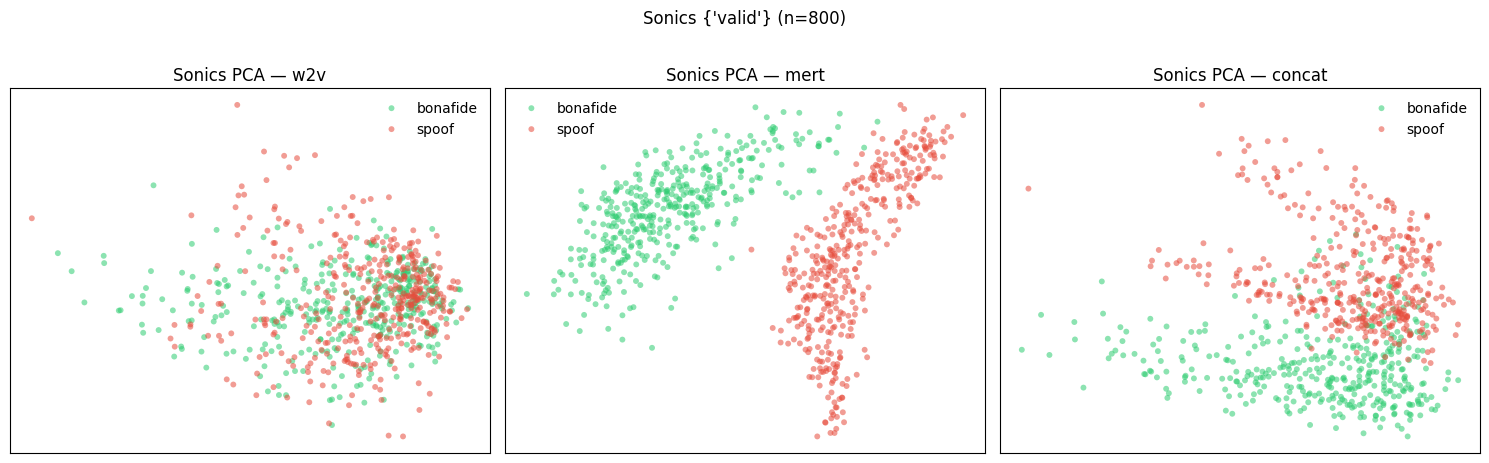

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, mod in zip(axes, MODALITIES):
    X, y = sonics_data[mod]
    Z = fit_embedding_2d(X, method="pca", cache_key=f"pca_sonics_{mod}_{N_PER_CLASS}")
    plot_scatter_2d(Z, y, f"Sonics PCA — {mod}", ax=ax)
fig.suptitle(f"Sonics {SONICS_SPLITS} (n={len(y)})", y=1.02)
plt.tight_layout()
plt.show()

## t-SNE 2D

Wolniejsze, ale lepiej pokazuje lokalną strukturę. Porównaj W2V vs MERT — który modal daje czytelniejsze klastry?

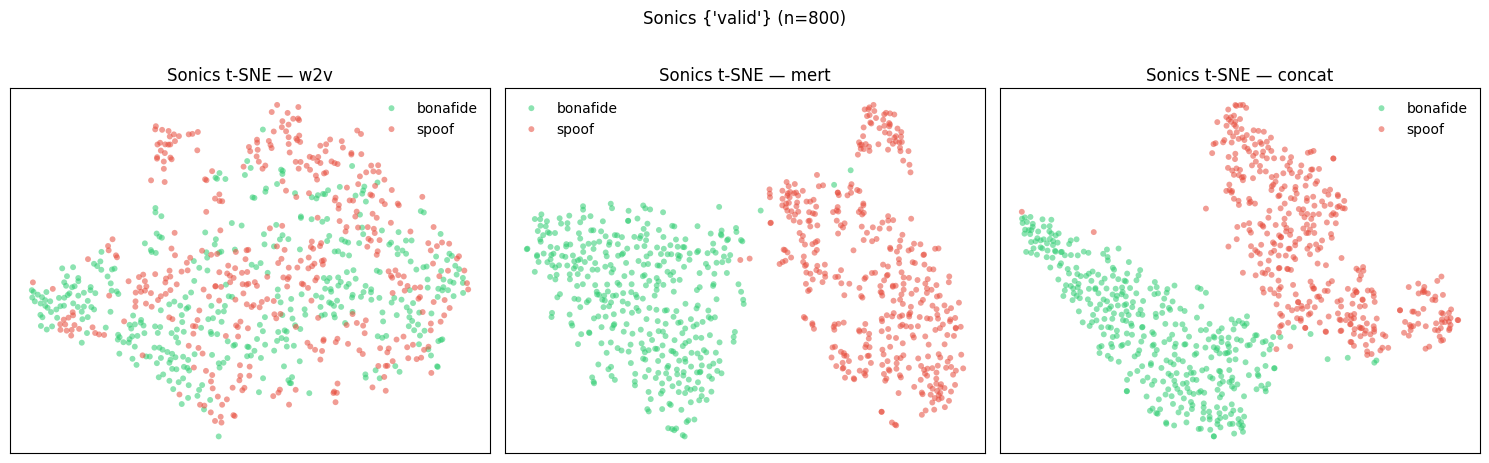

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, mod in zip(axes, MODALITIES):
    X, y = sonics_data[mod]
    Z = fit_embedding_2d(
        X, method="tsne",
        cache_key=f"tsne_sonics_{mod}_{N_PER_CLASS}",
    )
    plot_scatter_2d(Z, y, f"Sonics t-SNE — {mod}", ax=ax)
fig.suptitle(f"Sonics {SONICS_SPLITS} (n={len(y)})", y=1.02)
plt.tight_layout()
plt.show()

## MoM (OOD) — ten sam podgląd

Jeśli na Sonics widać separację, a na MoM nie — to typowy **domain shift**, nie brak sygnału w encoderach.

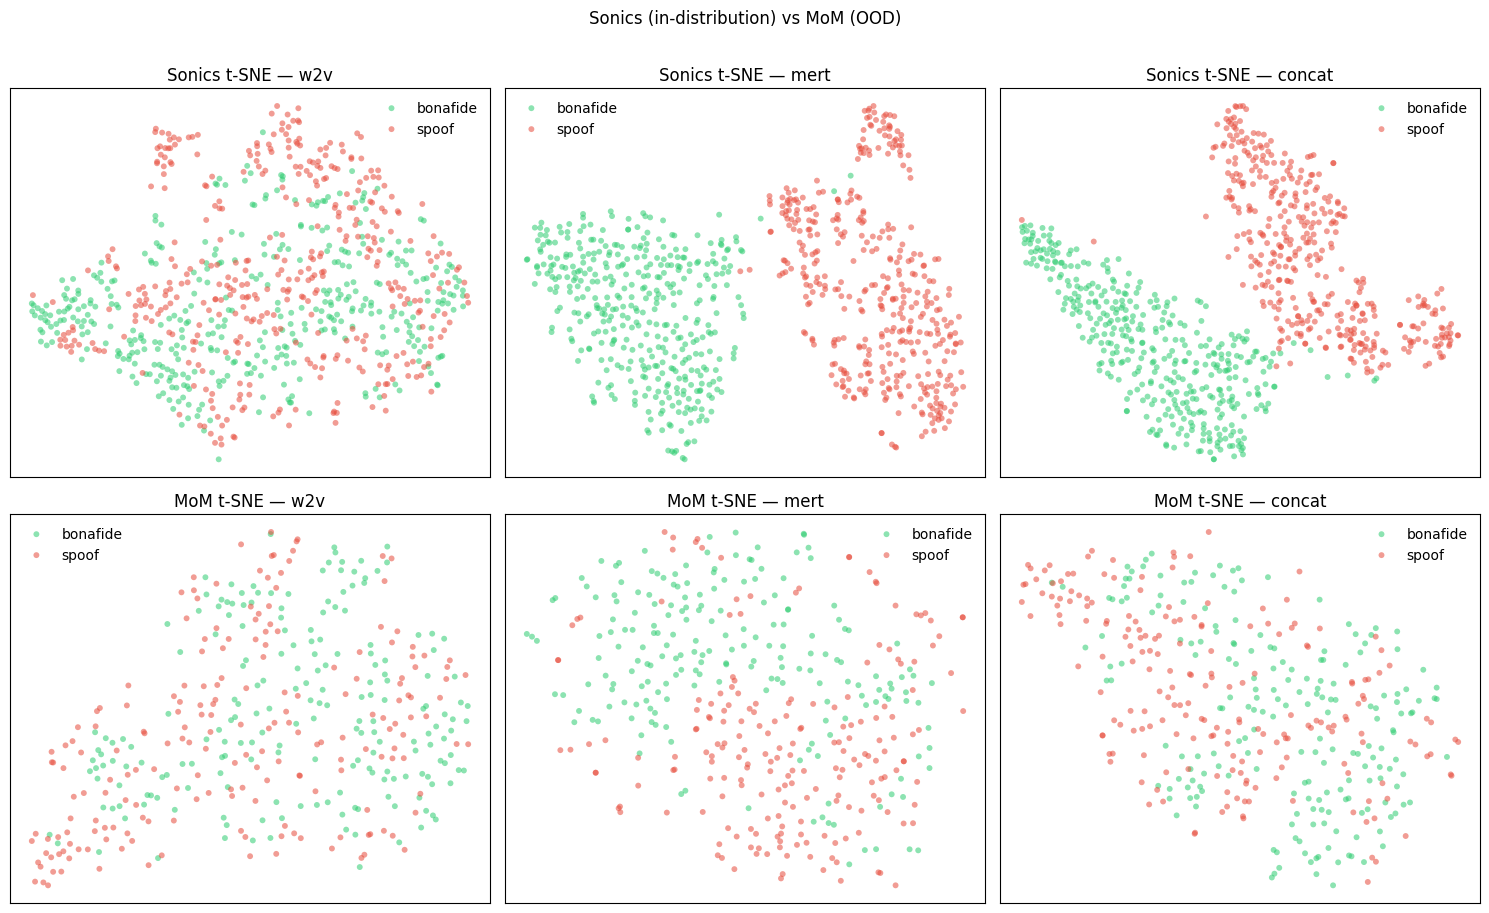

In [8]:
if mom_data:
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    for col, mod in enumerate(MODALITIES):
        X_s, y_s = sonics_data[mod]
        Z_s = fit_embedding_2d(X_s, method="tsne", cache_key=f"tsne_sonics_{mod}_{N_PER_CLASS}")
        plot_scatter_2d(Z_s, y_s, f"Sonics t-SNE — {mod}", ax=axes[0, col])

        X_m, y_m = mom_data[mod]
        Z_m = fit_embedding_2d(X_m, method="tsne", cache_key=f"tsne_mom_{mod}_{MOM_N_PER_CLASS}")
        plot_scatter_2d(Z_m, y_m, f"MoM t-SNE — {mod}", ax=axes[1, col])

    fig.suptitle("Sonics (in-distribution) vs MoM (OOD)", y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("INCLUDE_MOM=False — pomiń panel MoM")

## 5. Kierunek probe: Sonics train → projekcja 1D (valid + MoM)

Ten sam setup co `linear_probe.ipynb`: LR na **Sonics train**, potem rzutujemy próbki na oś `coef` (po StandardScaler).

- **Histogram 1D** — czy granica z train rozdziela klasy na valid (ID) i MoM (OOD)?
- **EER OOD** — powinien być zbliżony do `linear_probe` (przy tym samym `PROBE_TRAIN_PER_CLASS`).

To odpowiada na pytanie „czy MERT wygląda lepiej, bo ma inny kierunek, który **nie transferuje**?”

In [14]:
def make_probe_pipeline() -> Pipeline:
    return Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED)),
    ])


def fit_ood_probe(
    train_entries: list[dict],
    modality: str,
    train_per_class: int | None,
) -> tuple[Pipeline, np.ndarray, np.ndarray]:
    if train_per_class is None:
        train_sub = train_entries
        cache_tag = "full"
    else:
        train_sub = stratified_subsample(train_entries, train_per_class, RANDOM_SEED + 7)
        cache_tag = str(train_per_class)
    cache_key = f"probe_train_{modality}_{cache_tag}"
    X_tr, y_tr = build_matrix(train_sub, modality, cache_key=cache_key)
    clf = make_probe_pipeline()
    clf.fit(X_tr, y_tr)
    return clf, X_tr, y_tr


def probe_scores(clf: Pipeline, X: np.ndarray) -> np.ndarray:
    """P(spoof) — jak w linear_probe."""
    return clf.predict_proba(X)[:, 1]


def plot_score_distributions(
    scores: np.ndarray,
    y: np.ndarray,
    title: str,
    ax=None,
):
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 3.5))
    for label in (0, 1):
        s = scores[y == label]
        ax.hist(s, bins=30, alpha=0.55, color=COLORS[label], label=LABEL_NAMES[label], density=True)
    ax.axvline(0.5, color="k", ls="--", lw=0.8, alpha=0.6)
    ax.set_xlim(0, 1)
    ax.set_xlabel("P(spoof)")
    ax.set_ylabel("density")
    ax.set_title(title)
    ax.legend(frameon=False, fontsize=8)
    return ax


sonics_train_all = load_index_entries(SONICS_POOLED, parse_split_label, splits={"train"})
mom_all_entries = load_index_entries(MOM_POOLED, parse_split_label_mom) if INCLUDE_MOM else []

# valid subsample już mamy jako sonics_sub; MoM jako mom_sub
probe_rows = []
probe_clfs: dict[str, Pipeline] = {}

for mod in MODALITIES:
    clf, _, _ = fit_ood_probe(sonics_train_all, mod, PROBE_TRAIN_PER_CLASS)
    probe_clfs[mod] = clf

    X_valid, y_valid = sonics_data[mod]
    X_mom, y_mom = mom_data[mod] if mom_data else (None, None)

    s_valid = probe_scores(clf, X_valid)
    probe_rows.append({
        "modality": mod, "split": "sonics_valid_sub",
        "eer": compute_eer(s_valid, y_valid), "n": len(y_valid),
    })

    if X_mom is not None:
        s_mom = probe_scores(clf, X_mom)
        probe_rows.append({
            "modality": mod, "split": "mom_sub",
            "eer": compute_eer(s_mom, y_mom), "n": len(y_mom),
        })

        # pełny MoM — cache osobno, żeby zobaczyć EER jak w linear_probe
        X_mom_full, y_mom_full = build_matrix(mom_all_entries, mod, cache_key=f"mom_full_{mod}")
        s_mom_full = probe_scores(clf, X_mom_full)
        probe_rows.append({
            "modality": mod, "split": "mom_full",
            "eer": compute_eer(s_mom_full, y_mom_full), "n": len(y_mom_full),
        })

probe_eer_df = pd.DataFrame(probe_rows)
display(probe_eer_df.pivot(index="modality", columns="split", values="eer"))
print("Porównaj kolumnę mom_full z linear_probe.ipynb (train Sonics → MoM).")

w2v:   0%|          | 0/6000 [00:00<?, ?it/s]

w2v:   0%|          | 0/1098 [00:00<?, ?it/s]

mert:   0%|          | 0/6000 [00:00<?, ?it/s]

mert:   0%|          | 0/1098 [00:00<?, ?it/s]

concat:   0%|          | 0/6000 [00:00<?, ?it/s]

concat:   0%|          | 0/1098 [00:00<?, ?it/s]

split,mom_full,mom_sub,sonics_valid_sub
modality,,,
concat,0.207679,0.23,0.0025
mert,0.227712,0.25,0.0025
w2v,0.138398,0.15,0.0075


Porównaj kolumnę mom_full z linear_probe.ipynb (train Sonics → MoM).


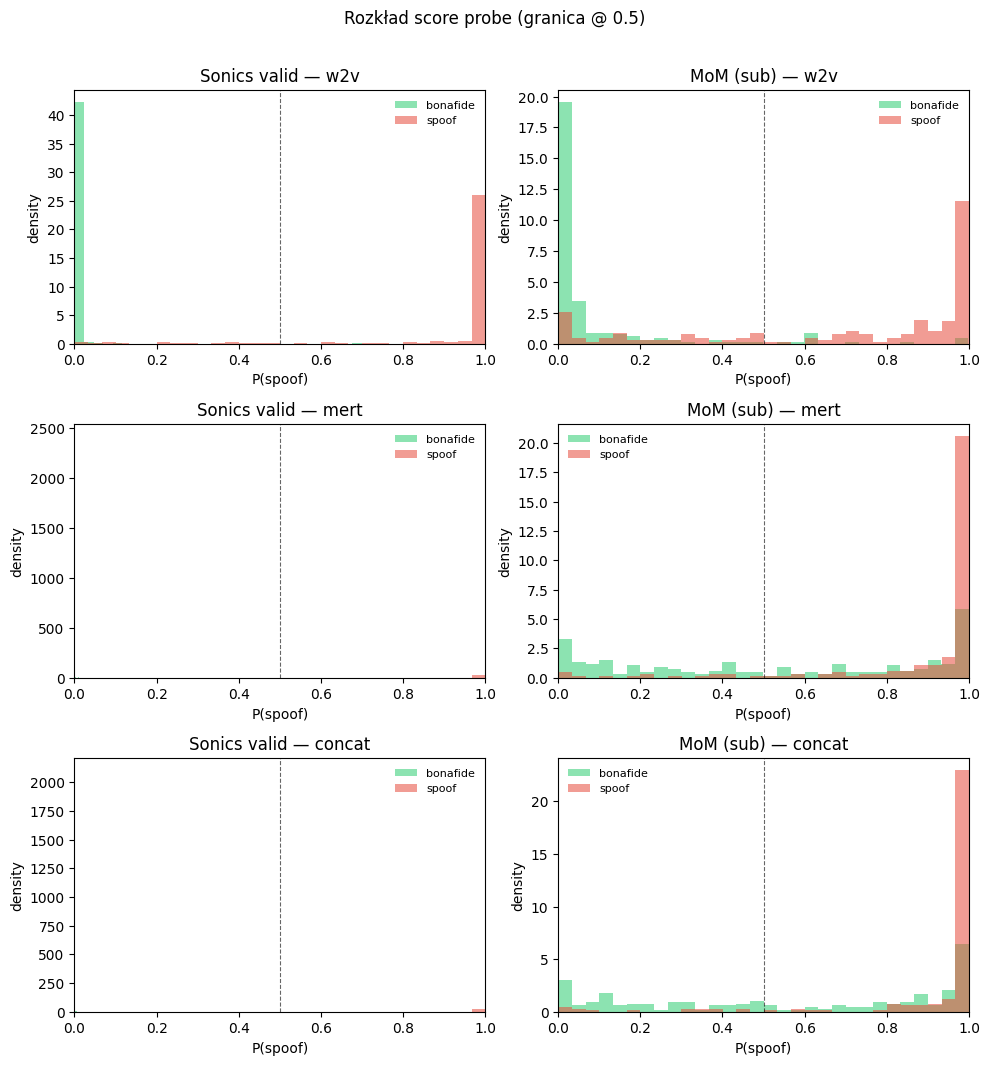

In [15]:
fig, axes = plt.subplots(len(MODALITIES), 2, figsize=(10, 3.5 * len(MODALITIES)), squeeze=False)

for row, mod in enumerate(MODALITIES):
    clf = probe_clfs[mod]
    X_valid, y_valid = sonics_data[mod]
    s_valid = probe_scores(clf, X_valid)
    plot_score_distributions(s_valid, y_valid, f"Sonics valid — {mod}", ax=axes[row, 0])

    if mom_data:
        X_mom, y_mom = mom_data[mod]
        s_mom = probe_scores(clf, X_mom)
        plot_score_distributions(s_mom, y_mom, f"MoM (sub) — {mod}", ax=axes[row, 1])
    else:
        axes[row, 1].set_visible(False)

fig.suptitle("Rozkład score probe (granica @ 0.5)", y=1.01)
plt.tight_layout()
plt.show()

## 6. Najbardziej informatywne wymiary

Dwa rankingi na **Sonics train** (ten sam podzbiór co probe):

| Metoda | Co mierzy |
|--------|-----------|
| **|coef LR|** (po scaler) | wymiary ważne **wielowymiarowo** (jak linear probe) |
| **Fisher ratio** | separacja **per wymiar** (średnie/ wariancje per klasa) |

Jeśli MERT ma ładne t-SNE, ale słaby OOD — często Fisher na ID jest wysoki na innych wymiarach niż te, które LR wybiera dla transferu. W2V vs MERT: mało overlapu w top-K → encodery widzą **różne** sygnały.

In [16]:
def fisher_scores(X: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Per-dim (mu1-mu0)^2 / (var0+var1) — univariate separability."""
    X0, X1 = X[y == 0], X[y == 1]
    mu0, mu1 = X0.mean(axis=0), X1.mean(axis=0)
    v0, v1 = X0.var(axis=0) + 1e-8, X1.var(axis=0) + 1e-8
    return (mu1 - mu0) ** 2 / (v0 + v1)


def top_dim_table(clf: Pipeline, X_train: np.ndarray, y_train: np.ndarray, modality: str, k: int) -> pd.DataFrame:
    lr = clf.named_steps["lr"]
    coef = np.abs(lr.coef_.ravel())
    fisher = fisher_scores(X_train, y_train)

    top_lr = np.argsort(coef)[::-1][:k]
    top_fisher = np.argsort(fisher)[::-1][:k]

    rows = []
    for rank in range(k):
        rows.append({
            "modality": modality,
            "rank": rank + 1,
            "dim_lr": int(top_lr[rank]),
            "coef_abs": float(coef[top_lr[rank]]),
            "dim_fisher": int(top_fisher[rank]),
            "fisher": float(fisher[top_fisher[rank]]),
        })
    return pd.DataFrame(rows)


def overlap_top_sets(a: np.ndarray, b: np.ndarray, k: int) -> int:
    return len(set(a[:k]) & set(b[:k]))


dim_tables = []
coef_maps = {}
fisher_maps = {}

for mod in MODALITIES:
    clf = probe_clfs[mod]
    cache_tag = "full" if PROBE_TRAIN_PER_CLASS is None else str(PROBE_TRAIN_PER_CLASS)
    X_tr, y_tr = build_matrix(
        stratified_subsample(sonics_train_all, PROBE_TRAIN_PER_CLASS, RANDOM_SEED + 7)
        if PROBE_TRAIN_PER_CLASS else sonics_train_all,
        mod,
        cache_key=f"probe_train_{mod}_{cache_tag}",
    )
    coef_maps[mod] = np.abs(clf.named_steps["lr"].coef_.ravel())
    fisher_maps[mod] = fisher_scores(X_tr, y_tr)
    dim_tables.append(top_dim_table(clf, X_tr, y_tr, mod, TOP_K_DIMS))

dim_report = pd.concat(dim_tables, ignore_index=True)
display(dim_report.groupby("modality").head(10))

# overlap rankingów między modalnościami (top-K wymiary LR)
for a, b in [("w2v", "mert"), ("w2v", "concat"), ("mert", "concat")]:
    idx_a = np.argsort(coef_maps[a])[::-1]
    idx_b = np.argsort(coef_maps[b])[::-1]
    ov = overlap_top_sets(idx_a, idx_b, TOP_K_DIMS)
    print(f"Overlap top-{TOP_K_DIMS} |coef| LR: {a} ∩ {b} = {ov}/{TOP_K_DIMS}")

,modality,rank,dim_lr,coef_abs,dim_fisher,fisher
0,w2v,1,587,0.673627,561,0.620854
1,w2v,2,360,0.556393,936,0.494022
2,w2v,3,286,0.510774,331,0.483810
3,w2v,4,661,0.507305,360,0.409031
4,w2v,5,486,0.494532,432,0.355416
5,w2v,6,507,0.493999,822,0.339307
6,w2v,7,532,0.488304,172,0.325107
7,w2v,8,259,0.487699,765,0.317799
8,w2v,9,82,0.482730,654,0.313375
9,w2v,10,181,0.477047,615,0.311535


Overlap top-25 |coef| LR: w2v ∩ mert = 0/25
Overlap top-25 |coef| LR: w2v ∩ concat = 1/25
Overlap top-25 |coef| LR: mert ∩ concat = 0/25


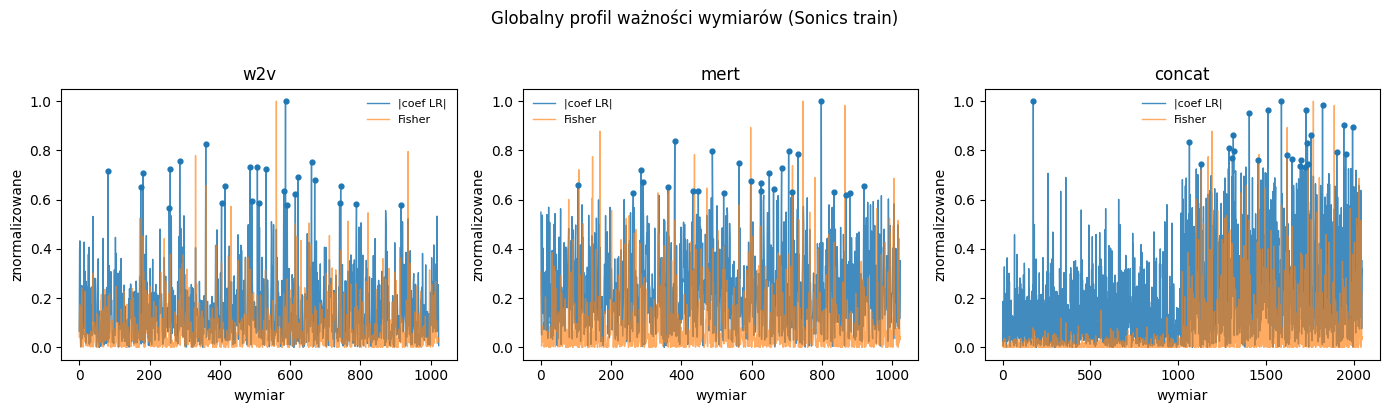

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, mod in zip(axes, MODALITIES):
    coef = coef_maps[mod]
    fisher = fisher_maps[mod]
    # normalizuj do [0,1] dla porównania kształtu
    c_norm = coef / (coef.max() + 1e-12)
    f_norm = fisher / (fisher.max() + 1e-12)
    dims = np.arange(len(coef))
    ax.plot(dims, c_norm, label="|coef LR|", alpha=0.85, lw=1)
    ax.plot(dims, f_norm, label="Fisher", alpha=0.65, lw=1)
    top = np.argsort(coef)[::-1][:TOP_K_DIMS]
    ax.scatter(top, c_norm[top], s=12, c="C0", zorder=3)
    ax.set_title(mod)
    ax.set_xlabel("wymiar")
    ax.set_ylabel("znormalizowane")
    ax.legend(frameon=False, fontsize=8)

fig.suptitle("Globalny profil ważności wymiarów (Sonics train)", y=1.02)
plt.tight_layout()
plt.show()

### Jak czytać sekcje 5–6

| Obserwacja | Interpretacja |
|------------|---------------|
| Sonics valid: score rozdzielone, MoM: mocne nakładanie | **domain shift** — sygnał jest, granica z train nie trzyma OOD |
| W2V: szersze rozdzielenie na MoM niż MERT | zgodne z niższym EER W2V w `linear_probe` |
| Fisher wysoki, ale |coef| LR niski na tym wymiarze | wymiar separuje sam, ale **koreluje ze śmieciem** — LR go ignoruje |
| Mały overlap top wymiarów W2V ∩ MERT | encodery komplementarne, ale concat nie pomaga OOD → MERT ciągnie w złą stronę |

**Na tym etapie to nie jest „totalnie useless”** — 1–2 komórki powyżej tłumaczą paradoks t-SNE vs probe. **Nie warto** na razie: SHAP na 1024D, głębokie ICA, autoencoder — ROI niski przed naprawą BiMamba / LoRA W2V.

## Opcjonalnie: UMAP

Często czytelniejszy niż t-SNE przy podobnym koszcie. Wymaga `pip install umap-learn`.

In [10]:
!uv pip install umap-learn

Resolved 10 packages in 452ms                                        
Prepared 2 packages in 66ms                                              
Installed 2 packages in 37ms                                
 + pynndescent==0.6.0
 + umap-learn==0.5.12


/net/pr2/projects/plgrid/plggaudiodfpwr/SVDD/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/net/pr2/projects/plgrid/plggaudiodfpwr/SVDD/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/net/pr2/projects/plgrid/plggaudiodfpwr/SVDD/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


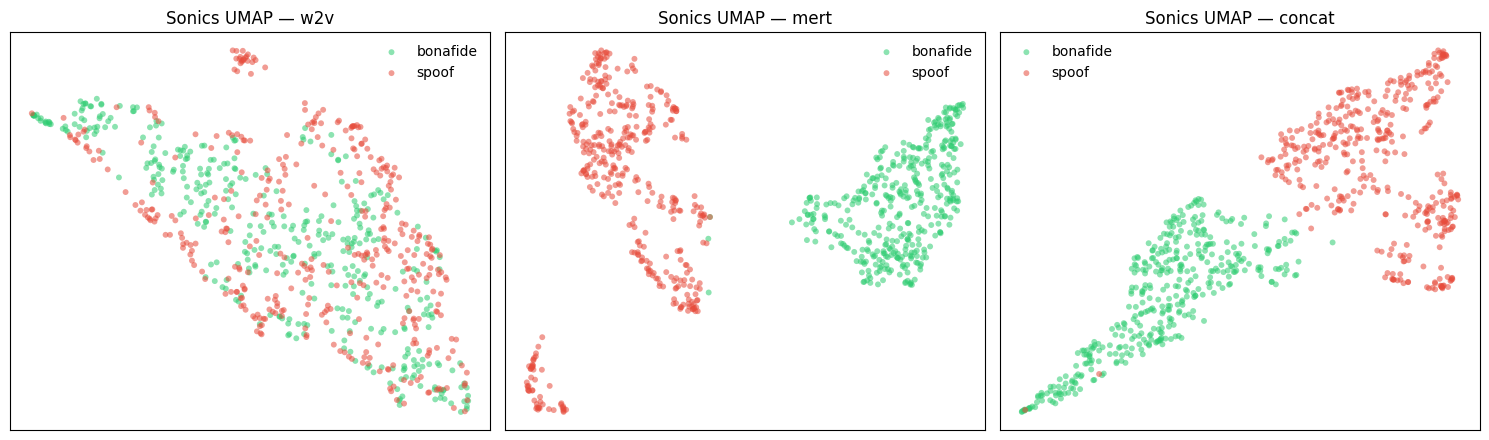

In [11]:
try:
    import umap
except ImportError:
    print("Brak umap-learn — uruchom: uv pip install umap-learn")
else:
    def fit_umap_2d(X, cache_key=None):
        if cache_key:
            path = CACHE_DIR / f"{cache_key}.npy"
            if path.exists():
                return np.load(path)
        Xs = StandardScaler().fit_transform(X)
        Z = umap.UMAP(n_components=2, random_state=RANDOM_SEED, n_neighbors=15, min_dist=0.1).fit_transform(Xs)
        if cache_key:
            np.save(CACHE_DIR / f"{cache_key}.npy", Z)
        return Z

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for ax, mod in zip(axes, MODALITIES):
        X, y = sonics_data[mod]
        Z = fit_umap_2d(X, cache_key=f"umap_sonics_{mod}_{N_PER_CLASS}")
        plot_scatter_2d(Z, y, f"Sonics UMAP — {mod}", ax=ax)
    plt.tight_layout()
    plt.show()